In [1]:
import numpy as np
import pandas as pd
# give you file path here
dataset = pd.read_csv('/content/customer_churn_dataset-training-master.csv')
dataset.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [2]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [3]:
print(dataset.isnull().sum())
print(dataset.describe())

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64
          CustomerID            Age         Tenure  Usage Frequency  \
count  440832.000000  440832.000000  440832.000000    440832.000000   
mean   225398.667955      39.373153      31.256336        15.807494   
std    129531.918550      12.442369      17.255727         8.586242   
min         2.000000      18.000000       1.000000         1.000000   
25%    113621.750000      29.000000      16.000000         9.000000   
50%    226125.500000      39.000000      32.000000        16.000000   
75%    337739.250000      48.000000      46.000000        23.000000   
max    449999.000000      65.000000      60.000000        30.000000   

       Support Calls  Payment Delay    Total Spend  Last Interaction  \

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


Churn
1.0    249999
0.0    190833
Name: count, dtype: int64


/tmp/ipykernel_2758/2545296422.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=dataset, palette='coolwarm')


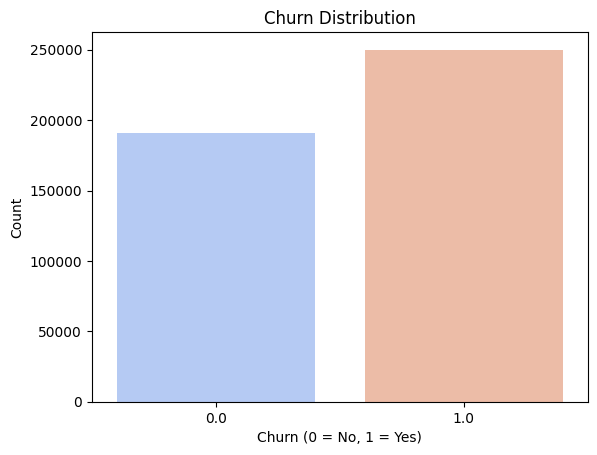

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

print(dataset['Churn'].value_counts())
sns.countplot(x='Churn', data=dataset, palette='coolwarm')
plt.title('Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

In [6]:
dataset['Total Spend'] = pd.to_numeric(dataset['Total Spend'], errors='coerce')
dataset['Total Spend'].fillna(dataset['Total Spend'].median(), inplace=True)

/tmp/ipykernel_2758/4152180848.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Total Spend'].fillna(dataset['Total Spend'].median(), inplace=True)


In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440833 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [8]:
from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()
categorical_cols = ['Subscription Type','Contract Length','Gender']
for col in categorical_cols:
    dataset[col] = labelencoder.fit_transform(dataset[col])

In [9]:
from sklearn.model_selection import train_test_split

X = dataset.drop(['CustomerID', 'Churn'], axis=1)
y = dataset['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [10]:
from sklearn.model_selection import train_test_split

y = dataset['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

In [11]:
from sklearn.model_selection import train_test_split

X = dataset.drop(['CustomerID', 'Churn'], axis=1)
y = dataset['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)


In [12]:
print(X_train["Gender"].unique())
print(X_test["Gender"].unique())

[1 0]
[1 0 2]


In [13]:
le = LabelEncoder()

for col in dataset.columns:
    if dataset[col].dtype == 'object':
        dataset[col] = le.fit_transform(dataset[col])

In [14]:
print(dataset.head())

   CustomerID   Age  Gender  Tenure  Usage Frequency  Support Calls  \
0         2.0  30.0       0    39.0             14.0            5.0   
1         3.0  65.0       0    49.0              1.0           10.0   
2         4.0  55.0       0    14.0              4.0            6.0   
3         5.0  58.0       1    38.0             21.0            7.0   
4         6.0  23.0       1    32.0             20.0            5.0   

   Payment Delay  Subscription Type  Contract Length  Total Spend  \
0           18.0                  2                0        932.0   
1            8.0                  0                1        557.0   
2           18.0                  0                2        185.0   
3            7.0                  2                1        396.0   
4            8.0                  0                1        617.0   

   Last Interaction  Churn  
0              17.0    1.0  
1               6.0    1.0  
2               3.0    1.0  
3              29.0    1.0  
4            

In [15]:
print(dataset.columns)

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')


In [16]:
X = dataset.drop(['CustomerID', 'Churn'], axis=1)
y = dataset['Churn']
print(X.head())

    Age  Gender  Tenure  Usage Frequency  Support Calls  Payment Delay  \
0  30.0       0    39.0             14.0            5.0           18.0   
1  65.0       0    49.0              1.0           10.0            8.0   
2  55.0       0    14.0              4.0            6.0           18.0   
3  58.0       1    38.0             21.0            7.0            7.0   
4  23.0       1    32.0             20.0            5.0            8.0   

   Subscription Type  Contract Length  Total Spend  Last Interaction  
0                  2                0        932.0              17.0  
1                  0                1        557.0               6.0  
2                  0                2        185.0               3.0  
3                  2                1        396.0              29.0  
4                  0                1        617.0              20.0  


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
print(X_train.isnull().sum())

Age                  1
Gender               0
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     1
dtype: int64


In [19]:
print(X_train.isnull().sum().sort_values(ascending=False))

Age                  1
Tenure               1
Last Interaction     1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Gender               0
Subscription Type    0
Contract Length      0
Total Spend          0
dtype: int64


In [20]:
print(y_train.isnull().sum())

1


In [21]:
X_train = X_train.fillna(X_train.mean(numeric_only=True))
X_test = X_test.fillna(X_train.mean(numeric_only=True))

In [22]:
X_train = X_train.fillna("Unknown")
X_test = X_test.fillna("Unknown")

In [23]:
print(X_train.isnull().sum())

Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
dtype: int64


In [24]:
print(X_train.shape)
print(y_train.shape)


(352666, 10)
(352666,)


In [25]:
print(X_train.dtypes)

Age                  float64
Gender                 int64
Tenure               float64
Usage Frequency      float64
Support Calls        float64
Payment Delay        float64
Subscription Type      int64
Contract Length        int64
Total Spend          float64
Last Interaction     float64
dtype: object


In [26]:
print(X_train.isnull().sum().sum())

0


In [27]:
print(y_train.isnull().sum())

1


In [28]:
print(X_train.head())

         Age  Gender  Tenure  Usage Frequency  Support Calls  Payment Delay  \
39267   31.0       0    60.0              9.0            9.0           15.0   
201478  21.0       0    20.0             15.0            5.0           13.0   
99810   47.0       0    10.0             26.0            7.0            8.0   
326974  36.0       1    28.0             17.0            2.0            4.0   
317912  50.0       1    20.0             21.0            4.0           14.0   

        Subscription Type  Contract Length  Total Spend  Last Interaction  
39267                   2                2       589.00              25.0  
201478                  2                0       715.03              14.0  
99810                   0                2       610.00              25.0  
326974                  2                2       967.79              21.0  
317912                  1                0       677.51              25.0  


In [29]:
print(X_train.select_dtypes(include='object').columns)

Index([], dtype='object')


In [30]:
import numpy as np

print(np.isinf(X_train).sum().sum())

0


In [31]:
print(y_train.unique())
print(y_train.dtype)

[ 1.  0. nan]
float64


In [32]:
print(X_train.dtypes)

Age                  float64
Gender                 int64
Tenure               float64
Usage Frequency      float64
Support Calls        float64
Payment Delay        float64
Subscription Type      int64
Contract Length        int64
Total Spend          float64
Last Interaction     float64
dtype: object


In [33]:
print(y_train.unique())
print(y_train.dtype)

[ 1.  0. nan]
float64


In [34]:
print(y_train.isnull().sum())


1


In [35]:
# Remove rows where the target is missing
mask = y.notna()

X = X[mask]
y = y[mask]

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
print(y_train.isnull().sum())

0


In [38]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [39]:
y_pred = clf.predict(X_test)

In [40]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9996824208604126
